In [15]:
from pynq import Overlay
ol = Overlay('pc_filter_bd_wrapper.bit')
dma    = ol.axi_dma_0
pc_flt = ol.pc_filter_0

In [16]:
import numpy as np
from PIL import Image

Y4M_PATH = 'TreesAndGrass_1920_1080_30fps_8bit.y4m'

with open(Y4M_PATH, 'rb') as f:
    f.readline()  # skip file header
    f.readline()  # skip FRAME header
    raw = f.read(1920 * 1080 * 3 // 2)

img_np = np.frombuffer(raw[:1920*1080], dtype=np.uint8).reshape(1080, 1920).copy()
H, W = img_np.shape
print(f"Image: {H}x{W}")

Image: 1080x1920


In [17]:
T = [2, 4, 9, 19, 44, 99, 230]
for i, t in enumerate(T):
    pc_flt.write(i * 4, int(t))
pc_flt.write(0x1C, (int(H) << 16) | int(W))
print("Registers written")

Registers written


In [18]:
from pynq import allocate

input_buf  = allocate(shape=(H * W,),         dtype=np.uint32)
output_buf = allocate(shape=((H-6)*(W-6),),   dtype=np.uint32)
input_buf[:] = img_np.flatten().astype(np.uint32)
print("Buffers allocated")

Buffers allocated


In [19]:
import time

dma.sendchannel._first_transfer = True
dma.recvchannel._first_transfer = True

dma.recvchannel.transfer(output_buf)
dma.sendchannel.transfer(input_buf)

t0 = time.time()
while not dma.sendchannel.idle:
    if time.time() - t0 > 5:
        print("Send timeout")
        break
    time.sleep(0.01)
else:
    print(f"Send done in {(time.time()-t0)*1000:.1f} ms")

Send done in 42.2 ms


In [21]:
mmio = dma.sendchannel._mmio
mm2s = mmio.read(0x04)
s2mm = mmio.read(0x34)
print(f"MM2S status: {mm2s:#010x}")
print(f"  DMAIntErr: {(mm2s>>4)&1}  DMASlvErr: {(mm2s>>5)&1}  DMADecErr: {(mm2s>>6)&1}")
print(f"S2MM status: {s2mm:#010x}")
print(f"  DMAIntErr: {(s2mm>>4)&1}  DMASlvErr: {(s2mm>>5)&1}  DMADecErr: {(s2mm>>6)&1}")
print(f"MM2S src addr : {mmio.read(0x18):#010x}")
print(f"MM2S length   : {mmio.read(0x28):#010x}")

MM2S status: 0x00001002
  DMAIntErr: 0  DMASlvErr: 0  DMADecErr: 0
S2MM status: 0x00001002
  DMAIntErr: 0  DMASlvErr: 0  DMADecErr: 0
MM2S src addr : 0x17900000
MM2S length   : 0x007e9000


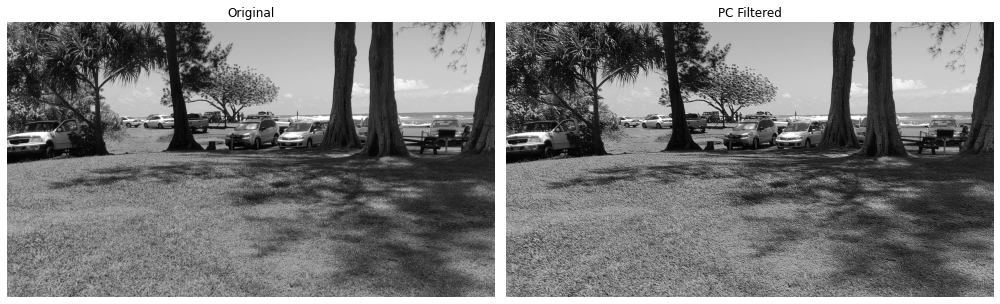

Diff: mean=0.157  std=46.056  min=-255  max=255


In [22]:
import matplotlib.pyplot as plt

# Extract filtered interior pixels
interior = (output_buf & 0xFF).astype(np.uint8).reshape(H-6, W-6)

# Overlay onto original (border pixels unchanged)
result = img_np.copy()
result[3:H-3, 3:W-3] = interior

# Display
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_np, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(result, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('PC Filtered')
axes[1].axis('off')
plt.tight_layout()
plt.show()

diff = result[3:-3, 3:-3].astype(np.int16) - img_np[3:-3, 3:-3].astype(np.int16)
print(f"Diff: mean={diff.mean():.3f}  std={diff.std():.3f}  min={diff.min()}  max={diff.max()}")

In [1]:
import os

# Find the extracted dataset
for root, dirs, files in os.walk('/home/xilinx/jupyter_notebooks'):
    for f in files:
        if f.endswith('.y') or f.endswith('_prelr.yuv') or f.endswith('.npz'):
            print(os.path.join(root, f))
    # Stop going too deep
    if root.count(os.sep) > 6:
        dirs.clear()

/home/xilinx/jupyter_notebooks/pc_filter/pc_qp_group_1.npz
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_HR/frame_107.y
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_HR/frame_045.y
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_HR/frame_013.y
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_HR/frame_111.y
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_HR/frame_023.y
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_HR/frame_096.y
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_HR/frame_081.y
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_HR/frame_116.y
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_HR/frame_027.y
/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/T